# 07 · Final evaluation of the chosen model

The final model is **DeBERTa-v3 base, trained with the `medium` preset** (9,000 reviews, 1 epoch, notebook 05). It was picked in notebook 04: macro-F1 0.752 on the test set, ahead of the 2-epoch version (0.738, notebook 06) and the best classical model (0.711).

This notebook looks at *how* it gets things right and wrong on the same 8,840 test reviews:

1. the full classification report
2. the confusion matrix (which classes get mixed up)
3. accuracy per star rating (1★ to 5★)
4. example reviews it gets right and wrong
5. a quick demo of `predict.py`

Predictions use `predict.py` from the project folder, so the notebook and the script always give the same answers. On a laptop CPU, predicting the test set takes roughly 20 to 40 minutes the first time (progress is printed); the predictions are then saved to `Output/final_predictions_deberta_v3_base_medium.csv` and re-runs are instant.

In [2]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
DATA, OUTPUT = ROOT / 'Data', ROOT / 'Output'
sys.path.insert(0, str(ROOT))
from predict import SentimentModel, LABELS, MODEL_NAME

model = SentimentModel()
print('model:', MODEL_NAME, '| cutoff offsets (not satisfied, neutral, satisfied):', model.offsets.round(2).tolist())

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

model: deberta_v3_base_medium | cutoff offsets (not satisfied, neutral, satisfied): [-1.0, -1.2, 0.0]


In [3]:
test = pd.read_csv(DATA / 'test.csv').dropna(subset=['text']).reset_index(drop=True)
test['title'] = test['title'].fillna('')
cache = OUTPUT / f'final_predictions_{MODEL_NAME}.csv'

if cache.exists() and len(pd.read_csv(cache)) == len(test):
    probs = pd.read_csv(cache)[[f'prob_{l}' for l in LABELS]].values
    print('loaded saved predictions from', cache.name)
else:
    probs = model.predict_proba(test['text'].astype(str).tolist(), test['title'].tolist(), progress=True)

test['pred'] = [LABELS[i] for i in (np.log(probs + 1e-12) + model.offsets).argmax(1)]
for j, l in enumerate(LABELS):
    test[f'prob_{l}'] = probs[:, j]
test['confidence'] = probs.max(1)
test[['id', 'stars', 'label', 'pred'] + [f'prob_{l}' for l in LABELS]].to_csv(cache, index=False)

reported = json.load(open(OUTPUT / 'results' / f'{MODEL_NAME}.json'))['macro_f1']
print(f"macro-F1 {f1_score(test.label, test.pred, average='macro'):.3f}  (notebook 05 reported {reported:.3f})")
print(classification_report(test.label, test.pred, labels=LABELS, digits=3))

400 / 8,840 reviews
800 / 8,840 reviews
1,200 / 8,840 reviews
1,600 / 8,840 reviews
2,000 / 8,840 reviews
2,400 / 8,840 reviews
2,800 / 8,840 reviews
3,200 / 8,840 reviews
3,600 / 8,840 reviews
4,000 / 8,840 reviews
4,400 / 8,840 reviews
4,800 / 8,840 reviews
5,200 / 8,840 reviews
5,600 / 8,840 reviews
6,000 / 8,840 reviews
6,400 / 8,840 reviews
6,800 / 8,840 reviews
7,200 / 8,840 reviews
7,600 / 8,840 reviews
8,000 / 8,840 reviews
8,400 / 8,840 reviews
8,800 / 8,840 reviews
macro-F1 0.752  (notebook 05 reported 0.752)
               precision    recall  f1-score   support

not satisfied      0.805     0.766     0.785      1081
      neutral      0.433     0.641     0.517       755
    satisfied      0.976     0.933     0.954      7004

     accuracy                          0.887      8840
    macro avg      0.738     0.780     0.752      8840
 weighted avg      0.909     0.887     0.896      8840



## Confusion matrix

Rows are the true label, columns the prediction. The right-hand plot shows each row as percentages, so the diagonal is the recall of each class.

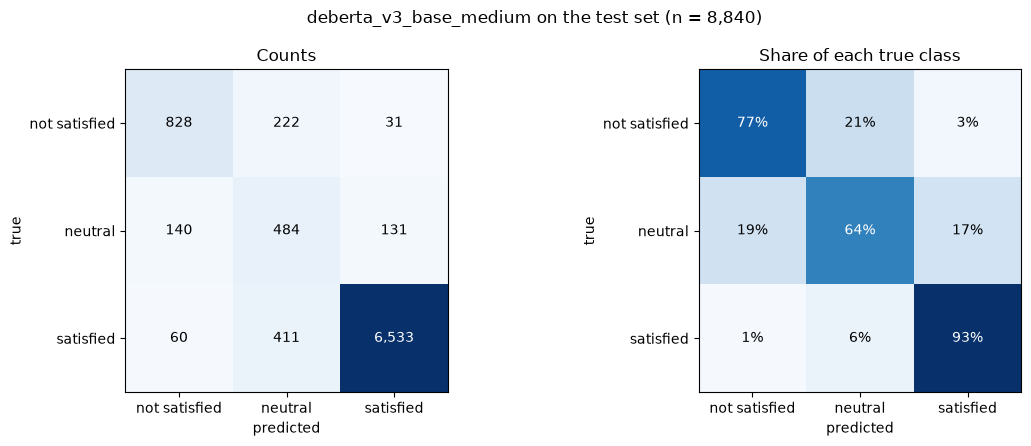

In [4]:
cm = confusion_matrix(test.label, test.pred, labels=LABELS)
cm_pct = cm / cm.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, m, title, fmt in [(axes[0], cm, 'Counts', '{:,.0f}'), (axes[1], cm_pct, 'Share of each true class', '{:.0%}')]:
    ax.imshow(m / m.max(), cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3), LABELS); ax.set_yticks(range(3), LABELS)
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, fmt.format(m[i, j]), ha='center', va='center', color='white' if m[i, j] / m.max() > 0.5 else 'black')
plt.suptitle(f'{MODEL_NAME} on the test set (n = {len(test):,})')
plt.tight_layout(); plt.savefig(OUTPUT / 'confusion_matrix_final.png', dpi=120); plt.show()

## Accuracy per star rating

Labels come from stars (1-2 not satisfied, 3 neutral, 4-5 satisfied). Looking at the stars separately shows *where* the errors are: the borders between classes (2★, 3★, 4★) are where reviewers' words and ratings disagree most.

In [5]:
by_star = (test.assign(correct=test.label == test.pred)
                .groupby('stars')
                .agg(reviews=('correct', 'size'), accuracy=('correct', 'mean')))
pred_mix = pd.crosstab(test.stars, test.pred, normalize='index').reindex(columns=LABELS, fill_value=0).add_prefix('predicted ')
by_star = by_star.join(pred_mix)
by_star.style.format({'accuracy': '{:.0%}', **{c: '{:.0%}' for c in pred_mix.columns}})

,reviews,accuracy,predicted not satisfied,predicted neutral,predicted satisfied
stars,,,,,
1,625,86%,86%,12%,3%
2,456,64%,64%,33%,3%
3,755,64%,19%,64%,17%
4,1315,75%,3%,23%,75%
5,5689,98%,0%,2%,98%


## Example reviews

For each true class: a few it gets right with high confidence, and the errors it was most confident about. Confident errors are often reviews whose words don't match their star rating (label noise), not model mistakes.

In [6]:
pd.set_option('display.max_colwidth', 180)
show = lambda df: df.assign(review=(df.title.where(df.title == '', df.title + ' | ') + df.text).str.slice(0, 180))[
    ['stars', 'label', 'pred', 'confidence', 'review']].round(2)

for label in LABELS:
    part = test[test.label == label]
    print(f'\n===== true: {label} =====')
    print('correct, most confident:')
    display(show(part[part.pred == label].nlargest(3, 'confidence')))
    print('wrong, most confident:')
    display(show(part[part.pred != label].nlargest(4, 'confidence')))


===== true: not satisfied =====
correct, most confident:


,stars,label,pred,confidence,review
7810,1,not satisfied,not satisfied,0.97,Garbage. Broke after 35 days and can't return it.
7193,1,not satisfied,not satisfied,0.96,Don't bother. | Waste of money. Accomplishes absolutely nothing.
8556,1,not satisfied,not satisfied,0.96,Worst purchase ever | It sucks dosent answer any questions


wrong, most confident:


,stars,label,pred,confidence,review
1852,1,not satisfied,satisfied,0.99,I use it everyday and I really do love it.
3607,1,not satisfied,satisfied,0.99,I love my Echo Dot...it surpassed my expectations....thank you!!!!
5295,2,not satisfied,satisfied,0.97,Alexa | Great. Was not disappointed in the least I probably could have used more..... Every household needs several.
6988,1,not satisfied,satisfied,0.96,Buy this device and see the good results it gives below. | Has good features when it works.



===== true: neutral =====
correct, most confident:


...

,stars,label,pred,confidence,review
5548,3,neutral,satisfied,0.98,Good deal | Really nice for the price
565,3,neutral,satisfied,0.98,Just love alexa.
2355,3,neutral,satisfied,0.98,"Great device, needs audio help | The Echo dot has been a great addition to our house. I original ordered a few of these when my daughter was born to automate the house so we di..."
4111,3,neutral,satisfied,0.98,"I enjoy my echo a lot | I enjoy my echo a lot, it does a lot of things. I enjoy it most for college as I ask a lot of questions and Alexa is able to give me the answers to them."



===== true: satisfied =====
correct, most confident:


,stars,label,pred,confidence,review
1540,5,satisfied,satisfied,0.99,Love it! | I love it! Great product!
2043,5,satisfied,satisfied,0.99,Love it! We use it all the time | Love it! We use it all the time!
2492,5,satisfied,satisfied,0.99,Great product! Absolutely love it | Great product! Absolutely love it!


wrong, most confident:


,stars,label,pred,confidence,review
4767,5,satisfied,not satisfied,0.96,Extremely disappointed. We just bought ours in December and never ... | Extremely disappointed. We just bought ours in December and never move it. It just stopped working last ...
7510,5,satisfied,not satisfied,0.95,"My Echo no longer echos | I have had it less than three months and it is no longer responding. I'm so disappointed, it hasn't been abused, not played with at all. It should be..."
3328,5,satisfied,not satisfied,0.94,Kids took it!!! Never to be seen again!!
2579,5,satisfied,not satisfied,0.94,Bad A$$ | Bad a$$


## Try it: `predict.py`

The same model from Python. From a terminal in the project folder you can also run:

```
python predict.py "Stopped working after two weeks"
python predict.py --file my_reviews.csv
```

In [7]:
examples = [
    'Love it! Alexa plays my music and controls the lights, works perfectly.',
    'It is ok. The speaker is weak but for the price it does the job.',
    'Stopped responding after two weeks and support was useless. Returning it.',
]
pd.DataFrame({'review': examples, 'prediction': model.predict(examples)})

,review,prediction
0,"Love it! Alexa plays my music and controls the lights, works perfectly.",satisfied
1,It is ok. The speaker is weak but for the price it does the job.,neutral
2,Stopped responding after two weeks and support was useless. Returning it.,not satisfied
